In [ ]:
import pandas as pd
from sklearn import decomposition
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from sklearn.cluster import KMeans
import numpy as np
from plotnine import *
import warnings


In [3]:
import warnings
warnings.filterwarnings("ignore", message="Could not find the number of physical cores")


In [4]:
# import Excel sheet
data = pd.read_csv("eeg-eye-state.csv")

In [5]:
# drop categorical column
data = data.drop(columns=["eyeDetection"])

In [6]:
# visualize data 
data.head()

,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4
0,4329.23,4009.23,4289.23,4148.21,4350.26,4586.15,4096.92,4641.03,4222.05,4238.46,4211.28,4280.51,4635.90,4393.85
1,4324.62,4004.62,4293.85,4148.72,4342.05,4586.67,4097.44,4638.97,4210.77,4226.67,4207.69,4279.49,4632.82,4384.10
2,4327.69,4006.67,4295.38,4156.41,4336.92,4583.59,4096.92,4630.26,4207.69,4222.05,4206.67,4282.05,4628.72,4389.23
3,4328.72,4011.79,4296.41,4155.90,4343.59,4582.56,4097.44,4630.77,4217.44,4235.38,4210.77,4287.69,4632.31,4396.41
4,4326.15,4011.79,4292.31,4151.28,4347.69,4586.67,4095.90,4627.69,4210.77,4244.10,4212.82,4288.21,4632.82,4398.46


In [7]:
# define variable that will standardize a series
def standardize(series):
    return (series - series.mean()) / series.std()

In [8]:
# standardize data set
data_standard = data.apply(standardize)
data_standard.head() # visualize to ensure all standard

,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4
0,0.002934,-0.011704,0.567380,-0.003208,0.245228,-0.019787,-0.002930,0.852539,0.001509,0.187743,0.233502,0.030744,0.017126,-0.003834
1,0.001084,-0.112048,0.671368,-0.003111,0.008893,-0.019609,-0.002817,0.782214,-0.003771,-0.122105,0.138493,0.006192,0.014577,-0.005489
2,0.002316,-0.067427,0.705806,-0.001636,-0.138781,-0.020662,-0.002930,0.484870,-0.005213,-0.243521,0.111499,0.067813,0.011184,-0.004618
3,0.002730,0.044019,0.728989,-0.001734,0.053224,-0.021014,-0.002817,0.502280,-0.000649,0.106799,0.220005,0.203571,0.014155,-0.003399
4,0.001698,0.044019,0.636705,-0.002620,0.171247,-0.019609,-0.003152,0.397134,-0.003771,0.335966,0.274258,0.216088,0.014577,-0.003051


In [9]:
# no need to do embeddings like previous problem set because csv is already numbers
pca_raw = decomposition.PCA() # performed on all components
pca = pd.DataFrame(
    pca_raw.fit_transform(data_standard)
)

In [26]:
pca.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,cluster
0,0.417793,-0.013065,0.288558,0.567410,0.435357,-0.120046,0.521994,0.151257,-0.224877,-0.264516,0.022224,0.006771,0.000246,0.011734,2
1,0.364204,-0.076547,0.326739,0.315702,0.255801,-0.220059,0.513467,0.313599,-0.435848,-0.313905,0.025137,0.004363,0.001548,0.009022,2
2,0.327206,-0.136215,0.350186,0.125139,0.103205,-0.138291,0.286483,0.406929,-0.452919,-0.295112,0.018836,0.002422,0.000851,0.008964,0
3,0.420266,-0.122798,0.395207,0.405395,0.295541,-0.017629,0.206967,0.366122,-0.224588,-0.250669,0.014771,0.001648,-0.000128,0.011608,2
4,0.404974,-0.093111,0.330075,0.481530,0.421499,0.033727,0.096210,0.280887,-0.027145,-0.219816,0.012952,0.003604,0.000074,0.010690,2


In [11]:
print(pca.columns.tolist())


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]


In [12]:
# plot PCA0 vs PCA1

fig = make_subplots(rows=1, cols=1)

fig.add_trace(
    go.Scatter(
        x=pca[0],
        y=pca[1],
        mode='markers',
        marker=dict(size=6, opacity=0.7),
        name="PCA Points"
    ),
    row=1, col=1
)

fig.update_layout(
    title="EEG Eye State - PC0 vs PC1",
    xaxis_title="PC0",
    yaxis_title="PC1",
    template="plotly_white"
)

fig.write_image('Original_PCA.png')
fig.show()


In [13]:
# zoom in near origin
fig = make_subplots(rows=1, cols=1)

fig.add_trace(
    go.Scatter(
        x=pca[0],
        y=pca[1],
        mode='markers',
        marker=dict(size=6, opacity=0.7),
        name="PCA Points"
    ),
    row=1, col=1
)

fig.update_layout(
    title="EEG Eye State - PC0 vs PC1",
    xaxis_title="PC0",
    yaxis_title="PC1",
    template="plotly_white",
    xaxis_range=[-2, 4],
    yaxis_range=[-1.5,1.5],
    width=800,
    height=800
)

fig.write_image('Zoom_PCA.png')
fig.show()


In [27]:
# implement k-means clustering with sklearn library. 
# k=7; init=random
# https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html

kmeans = KMeans(n_clusters=7, init="random", random_state=0).fit(data_standard)

In [15]:
# # Asked ChatGPT how to make scatterplot of kmeans, order the legend and add center of clusters
# add cluster to PCA dataframe
# makes string so can be plotted as discrete and not continuous

pca["cluster"] = kmeans.labels_
pca["cluster"] = pca["cluster"].astype(str) # makes string so can be plotted as discrete and not continuous


cluster_order = [str(i) for i in range(7)]  # Specifying order of clusters for legend


In [ ]:
# adds center 
# asked ChatGPT how to make it plottable
centers_pca = pca_raw.transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers_pca[:, :2], columns=['PCA0', 'PCA1'])

c:\Users\carol\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning:

X does not have valid feature names, but PCA was fitted with feature names



In [37]:
centers_df

,PCA0,PCA1
0,-0.141993,-0.016263
1,135.115917,-8.777743
2,0.390867,0.112231
3,0.433912,-0.192947
4,-0.473280,-0.086441
5,-32.723770,138.169825
6,2.061444,0.398914


In [17]:
pca.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,cluster
0,0.417793,-0.013065,0.288558,0.567410,0.435357,-0.120046,0.521994,0.151257,-0.224877,-0.264516,0.022224,0.006771,0.000246,0.011734,2
1,0.364204,-0.076547,0.326739,0.315702,0.255801,-0.220059,0.513467,0.313599,-0.435848,-0.313905,0.025137,0.004363,0.001548,0.009022,2
2,0.327206,-0.136215,0.350186,0.125139,0.103205,-0.138291,0.286483,0.406929,-0.452919,-0.295112,0.018836,0.002422,0.000851,0.008964,0
3,0.420266,-0.122798,0.395207,0.405395,0.295541,-0.017629,0.206967,0.366122,-0.224588,-0.250669,0.014771,0.001648,-0.000128,0.011608,2
4,0.404974,-0.093111,0.330075,0.481530,0.421499,0.033727,0.096210,0.280887,-0.027145,-0.219816,0.012952,0.003604,0.000074,0.010690,2


In [30]:
# Rename your PCA columns so they have valid names
pca = pca.rename(columns={0: "PCA0", 1: "PCA1"})

c:\Users\carol\anaconda3\Lib\site-packages\plotnine\layer.py:374: PlotnineWarning:

geom_point : Removed 4 rows containing missing values.

c:\Users\carol\anaconda3\Lib\site-packages\plotnine\layer.py:374: PlotnineWarning:

geom_point : Removed 2 rows containing missing values.



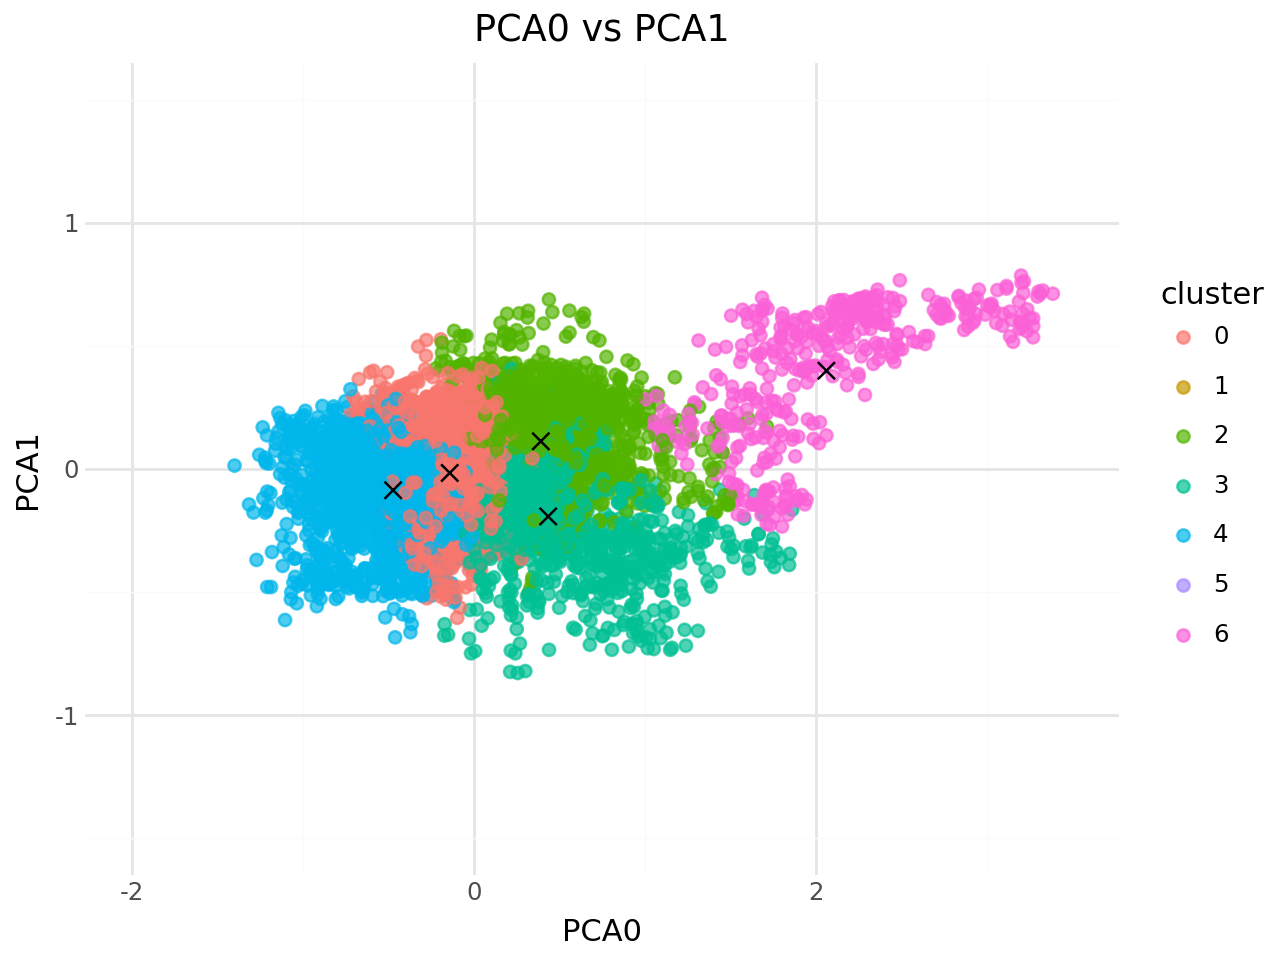

In [38]:
graph = (
    ggplot(pca, aes(x='PCA0', y='PCA1', color='cluster')) 
    + geom_point(size=2, alpha=0.7) 
    + geom_point(
        data=centers_df,
        mapping=aes(x='PCA0', y='PCA1'),
        shape='x', 
        size=3,  
        color='black' 
    ) 
    + labs(
    x='PCA0',
    y='PCA1',
    title = 'PCA0 vs PCA1'
) + theme_minimal()
+ xlim(-2, 3.5)
+ ylim(-1.5, 1.5)
)
graph

In [19]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

# Make sure cluster labels are strings for categorical plotting
pca["cluster"] = kmeans.labels_.astype(str)

# Define the order of clusters for the legend
cluster_order = [str(i) for i in range(7)]

# Create base scatterplot of PCA points
fig = px.scatter(
    pca,
    x=0,
    y=1,
    color="cluster",
    category_orders={"cluster": cluster_order},
    color_discrete_sequence=px.colors.qualitative.Dark24,
    opacity=0.7,
    title="EEG Eye State - PCA with KMeans Clusters"
)
centers_df = pd.DataFrame(
    centers_pca[:, :2],           # only first two PCs for 2D plotting
    columns=["PC0", "PC1"]
)
centers_df["cluster"] = [str(i) for i in range(7)]  # label each cluster 0–6
for i, row in centers_df.iterrows():
    fig.add_trace(
        go.Scatter(
            x=[row["PC0"]],
            y=[row["PC1"]],
            mode="markers",
            marker=dict(size=15, symbol="x", color="black"),
            name=f"Center {i}",
            showlegend=True
        )
    )

# Optional: zoom in near origin
fig.update_layout(
    width=900,
    height=700,
    xaxis_range=[-2, 4],
    yaxis_range=[-1.5, 1.5],
    template="plotly_white"
)

fig.show()


In [20]:
# The cluster not seen (cluster 3) is in the 3D dimensional space we cannot visualize in a 2D plot - it is behind the other clusters

In [21]:
# The centers are also behind the other clusters 